# Get distance of PCG to ncRNA

### Author: Martin Loza
### Date: 25/12/05

These distances will be used in further analyses

In [31]:
# Change R language to English
Sys.setenv(LANGUAGE = "en")

# Init
suppressPackageStartupMessages({
    library(dplyr)
    library(stringr)
    library(ggplot2)
    library(progress)
})

# Local variables
seed = 777
date = "251205"

in_dir = "/Users/martin/Documents/Projects/lncRNA_TF_pairs_analysis/Data/ENSEMBL/selected/"
out_dir = "/Users/martin/Documents/Projects/lncRNA_TF_pairs_analysis/Data/ENSEMBL/distances/"

# Local functions

# Function to calculate distances between ncRNA and nearby PCG (within a fixed distance)
calculate_pcg_ncrna_distances <- function(data, max_distance = 1e6) {
    # Filter PCG and ncRNA
    pcg_data <- data %>% filter(is_pcg == TRUE)
    ncrna_data <- data %>% filter(is_ncrna == TRUE)
    
    cat("Number of PCG:", nrow(pcg_data), "\n")
    cat("Number of ncRNA:", nrow(ncrna_data), "\n")
    
    # Get unique chromosomes
    chromosomes <- unique(ncrna_data$Chromosome.scaffold.name)
    cat("Number of chromosomes:", length(chromosomes), "\n")
    
    # Initialize list to store distance data
    distance_list <- list()
    
    # Create progress bar
    pb <- progress_bar$new(
        format = "  Processing [:bar] :percent eta: :eta",
        total = length(chromosomes),
        clear = FALSE,
        width = 60
    )
    
    # Process each chromosome
    for (chr in chromosomes) {
        # Update progress bar
        pb$tick()
        
        # Get ncRNAs and PCGs on this chromosome
        ncrna_chr <- ncrna_data %>% filter(Chromosome.scaffold.name == chr)
        pcg_chr <- pcg_data %>% filter(Chromosome.scaffold.name == chr)
        
        # Skip if no PCGs on this chromosome
        if (nrow(pcg_chr) == 0) next
        
        # Process each ncRNA on this chromosome
        for (i in 1:nrow(ncrna_chr)) {
            # Get ncRNA info
            ncrna_tss <- as.integer(ncrna_chr$TSS[i])
            ncrna_id <- ncrna_chr$Transcript.stable.ID[i]
            ncrna_gene_biotype <- ncrna_chr$Transcript.type[i]
            ncrna_gene_name <- ncrna_chr$Gene.name[i]
            ncrna_strand <- ncrna_chr$Strand[i]
            
            # Calculate DNA distances (PCG TSS - ncRNA TSS)
            dna_distances <- as.integer(pcg_chr$TSS) - ncrna_tss
            
            # Calculate strand-corrected distances
            # For reverse strand, flip the sign so positive = downstream in gene direction
            if (ncrna_strand == "-1") {
                strand_distances <- -dna_distances
            } else {
                strand_distances <- dna_distances
            }
            
            # Filter by maximum distance (using absolute DNA distance)
            in_window <- abs(dna_distances) <= max_distance
            
            if (sum(in_window) > 0) {
                # Store the data
                distance_list[[length(distance_list) + 1]] <- data.frame(
                    chromosome = chr,
                    ncRNA_id = ncrna_id,
                    ncrna_tss = ncrna_tss,
                    ncrna_gene_name = ncrna_gene_name,
                    ncrna_strand = ncrna_strand,
                    gene_biotype = ncrna_gene_biotype,
                    pcg_id = pcg_chr$Transcript.stable.ID[in_window],
                    pcg_gene_name = pcg_chr$Gene.name[in_window],
                    pcg_tss = pcg_chr$TSS[in_window],
                    dna_distance = dna_distances[in_window],
                    strand_distance = strand_distances[in_window],
                    stringsAsFactors = FALSE
                )
            }
        }
    }
    
    # Combine all distance data
    if (length(distance_list) > 0) {
        all_distances <- do.call(rbind, distance_list)
        cat("\nTotal ncRNA-PCG pairs within", max_distance/1e6, "Mb:", nrow(all_distances), "\n")
        return(all_distances)
    } else {
        warning("No PCG found within the specified distance from any ncRNA")
        return(NULL)
    }
}


### Load and setup the data

In [32]:
# Load the setup transcripts data
# We have different species, so let's create a list to store the data
data_list = list()

# Search for the available files
files <- list.files(in_dir)

# Load the data for each species
for (file in files) {
    # Remove the underscore and everything after it to get the species names
    species_name <- str_replace(file, "_.*", "")
    data_list[[species_name]] <- read.table(file.path(in_dir, file), sep = "\t", header = TRUE, 
                                            stringsAsFactors = FALSE, quote = "", 
                                            comment.char = "", fill = TRUE, row.names = NULL)
}

head(data_list[["dog"]], 3)


,row.names,Chromosome.scaffold.name,Gene.start..bp.,Gene.end..bp.,Strand,Gene.stable.ID,Transcript.stable.ID,Transcript.start..bp.,Transcript.end..bp.,Transcript.type,Gene.type,Gene.name,Gene.description,TSS,is_pcg,is_ncrna
,<chr>,<chr>,<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<int>,<lgl>,<lgl>
1,1,1,48283,118098,-1,ENSCAFG00845000008,ENSCAFT00845000010,48283,118098,protein_coding,protein_coding,ENPP1,ectonucleotide pyrophosphatase/phosphodiesterase 1 [Source:UniProtKB Gene Name;Acc:A0A8I3RQK2],118098,TRUE,FALSE
2,2,1,48283,118098,-1,ENSCAFG00845000008,ENSCAFT00845000011,49956,118098,protein_coding,protein_coding,ENPP1,ectonucleotide pyrophosphatase/phosphodiesterase 1 [Source:UniProtKB Gene Name;Acc:A0A8I3RQK2],118098,TRUE,FALSE
3,3,1,48283,118098,-1,ENSCAFG00845000008,ENSCAFT00845000016,49956,118098,protein_coding,protein_coding,ENPP1,ectonucleotide pyrophosphatase/phosphodiesterase 1 [Source:UniProtKB Gene Name;Acc:A0A8I3RQK2],118098,TRUE,FALSE


In [33]:
data_list[["mouse"]] %>% 
    filter(Gene.type == "lncRNA")  %>% filter(Gene.name	 == "Zfas1") %>%
    select(Gene.type , Gene.name, Transcript.stable.ID, Chromosome.scaffold.name,
        Transcript.start..bp., Transcript.end..bp., Strand, TSS)

Gene.type,Gene.name,Transcript.stable.ID,Chromosome.scaffold.name,Transcript.start..bp.,Transcript.end..bp.,Strand,TSS
<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>
lncRNA,Zfas1,ENSMUST00000125841,2,166905116,166907783,1,166905116
lncRNA,Zfas1,ENSMUST00000136378,2,166905141,166907782,1,166905141
lncRNA,Zfas1,ENSMUST00000143587,2,166905132,166907782,1,166905132
lncRNA,Zfas1,ENSMUST00000145859,2,166905138,166907782,1,166905138
lncRNA,Zfas1,ENSMUST00000189909,2,166904830,166907799,1,166904830
lncRNA,Zfas1,ENSMUST00000238277,2,166905137,166907783,1,166905137
lncRNA,Zfas1,ENSMUST00000243795,2,166905140,166907782,1,166905140
lncRNA,Zfas1,ENSMUST00000246977,2,166905132,166907783,1,166905132
lncRNA,Zfas1,ENSMUST00000247381,2,166905137,166907783,1,166905137


Let's focus on ncRNA and protein coding genes. 
We already classify them and labeled them usin the columns is_pcg and is_ncrna.

Let's also set TSS as integer.

In [34]:
# Setup the data
data_list_selected <- lapply(data_list, function(x){
    # Select only PCGs and ncRNAs
    x <- x %>% filter(is_pcg == TRUE | is_ncrna == TRUE)
    # Set TSS as integer
    x$TSS <- as.integer(x$TSS)
    # Set Strand as character
    x$Strand <- as.character(x$Strand)
    return(x)
})


In [35]:
# Example in mouse annotations
cat("Is_PCG:\n")
table(data_list_selected[["mouse"]]$is_pcg)
cat("Is_ncrna:\n")
table(data_list_selected[["mouse"]]$is_ncrna)

Is_PCG:



 FALSE   TRUE 
158258  58697 

Is_ncrna:



 FALSE   TRUE 
 58697 158258 

### Get the distance of PCGs to ncRNA

We will set a maximum distance of 1Mb. We will also get a strand corrected distance 

In [36]:
names(data_list)

[1] "armadillo"  "chicken"    "dog"        "drosophila" "elegans"   
 [6] "ferret"     "human"      "macaque"    "mouse"      "rat"       
[11] "zebrafish"

In [37]:
max_distance = "1000000"
# Let's use the calculate_pcg_ncrna_distances function
distances_list <- lapply(data_list, function(data){
# distances_list <- lapply(data_list[9], function(data){

    distances <- calculate_pcg_ncrna_distances(data, max_distance = as.numeric(max_distance))  # 1 Mb
})
names(distances_list) <- names(data_list)
# names(distances_list) <- "mouse"

Number of PCG: 26551 
Number of ncRNA: 9672 
Number of chromosomes: 2829 

Total ncRNA-PCG pairs within 1 Mb: 97005 
Number of PCG: 44876 
Number of ncRNA: 27748 
Number of chromosomes: 95 

Total ncRNA-PCG pairs within 1 Mb: 2255953 
Number of PCG: 43458 
Number of ncRNA: 11172 
Number of chromosomes: 96 

Total ncRNA-PCG pairs within 1 Mb: 478159 
Number of PCG: 30802 
Number of ncRNA: 4536 
Number of chromosomes: 17 

Total ncRNA-PCG pairs within 1 Mb: 2222315 
Number of PCG: 31865 
Number of ncRNA: 25857 
Number of chromosomes: 7 

Total ncRNA-PCG pairs within 1 Mb: 13916420 
Number of PCG: 20062 
Number of ncRNA: 13218 
Number of chromosomes: 571 

Total ncRNA-PCG pairs within 1 Mb: 206590 
Number of PCG: 221639 
Number of ncRNA: 203343 
Number of chromosomes: 467 

Total ncRNA-PCG pairs within 1 Mb: 36771781 
Number of PCG: 48600 
Number of ncRNA: 14018 
Number of chromosomes: 219 

Total ncRNA-PCG pairs within 1 Mb: 587785 
Number of PCG: 58697 
Number of ncRNA: 158258 
Number o

In [39]:
# save the distances for further analysis
for(i in seq_along(distances_list)){
    # get current species
    c_species <- names(distances_list)[i]
    # get the current distances
    c_distances <- distances_list[[i]]
    # create name of output file
    out_file <- paste0(out_dir,"all_transcripts/", c_species, "_max_", max_distance, "_", date, ".tsv")
    # save the table
    write.table(c_distances, file = out_file, sep = "\t", append = FALSE, quote = FALSE, row.names = FALSE, col.names = TRUE) 
}

### Some filters

#### Filter to nearest transcript per PCG gene

To reduce bias from multiple TSS of the same PCG, we'll keep only the nearest transcript for each PCG gene relative to each ncRNA.


In [45]:
# Filter distances to keep only the nearest transcript per PCG gene for each ncRNA
distances_list_filtered <- lapply(distances_list, function(distances) {
    if (is.null(distances)) return(NULL)
    
    cat("Original pairs:", nrow(distances), "\n")
    
    # For each ncRNA, keep only the nearest transcript of each PCG gene
    filtered <- distances %>%
        group_by(ncRNA_id, pcg_gene_name) %>%
        slice_min(abs(dna_distance), n = 1, with_ties = FALSE) %>%
        ungroup()
    
    cat("Filtered pairs (nearest per gene):", nrow(filtered), "\n")
    cat("Reduction:", round((1 - nrow(filtered)/nrow(distances)) * 100, 2), "%\n\n")
    
    return(filtered)
})
names(distances_list_filtered) <- names(distances_list)


Original pairs: 97005 
Filtered pairs (nearest per gene): 63908 
Reduction: 34.12 %

Original pairs: 2255953 
Filtered pairs (nearest per gene): 749464 
Reduction: 66.78 %

Original pairs: 478159 
Filtered pairs (nearest per gene): 195736 
Reduction: 59.06 %

Original pairs: 2222315 
Filtered pairs (nearest per gene): 1023152 
Reduction: 53.96 %

Original pairs: 13916420 
Filtered pairs (nearest per gene): 8441893 
Reduction: 39.34 %

Original pairs: 206590 
Filtered pairs (nearest per gene): 173505 
Reduction: 16.01 %

Original pairs: 36771781 
Filtered pairs (nearest per gene): 3464856 
Reduction: 90.58 %

Original pairs: 587785 
Filtered pairs (nearest per gene): 224385 
Reduction: 61.83 %

Original pairs: 9272232 
Filtered pairs (nearest per gene): 3352705 
Reduction: 63.84 %

Original pairs: 1912310 
Filtered pairs (nearest per gene): 773707 
Reduction: 59.54 %

Original pairs: 611459 
Filtered pairs (nearest per gene): 324774 
Reduction: 46.89 %



In [46]:
# Compare before and after filtering for one species
cat("Example: Human\n")
cat("Before filtering:\n")
cat("  Total pairs:", nrow(distances_list[["human"]]), "\n")
cat("  Unique PCG genes:", length(unique(distances_list[["human"]]$pcg_gene_name)), "\n")
cat("  Unique PCG transcripts:", length(unique(distances_list[["human"]]$pcg_id)), "\n\n")
cat("After filtering:\n")
cat("  Total pairs:", nrow(distances_list_filtered[["human"]]), "\n")
cat("  Unique PCG genes:", length(unique(distances_list_filtered[["human"]]$pcg_gene_name)), "\n")
cat("  Unique PCG transcripts:", length(unique(distances_list_filtered[["human"]]$pcg_id)), "\n")

Example: Human
Before filtering:
  Total pairs: 36771781 
Before filtering:
  Total pairs: 36771781 
  Unique PCG genes: 19402 
  Unique PCG genes: 19402 
  Unique PCG transcripts: 221214 

After filtering:
  Total pairs: 3464856 
  Unique PCG transcripts: 221214 

After filtering:
  Total pairs: 3464856 
  Unique PCG genes: 19402 
  Unique PCG genes: 19402 
  Unique PCG transcripts: 46967 
  Unique PCG transcripts: 46967 


In [57]:
# save the filtered distances for further analysis
for(i in seq_along(distances_list_filtered)){
    # get current species
    c_species <- names(distances_list_filtered)[i]
    # get the current distances
    c_distances <- distances_list_filtered[[i]]
    # create name of output file
    out_file <- paste0(out_dir,"single_pcg_gene_transcripts/", c_species, "_max_", max_distance, "_", date, ".tsv")
    # save the table
    write.table(c_distances, file = out_file, sep = "\t", append = FALSE, quote = FALSE, row.names = FALSE, col.names = TRUE) 
}

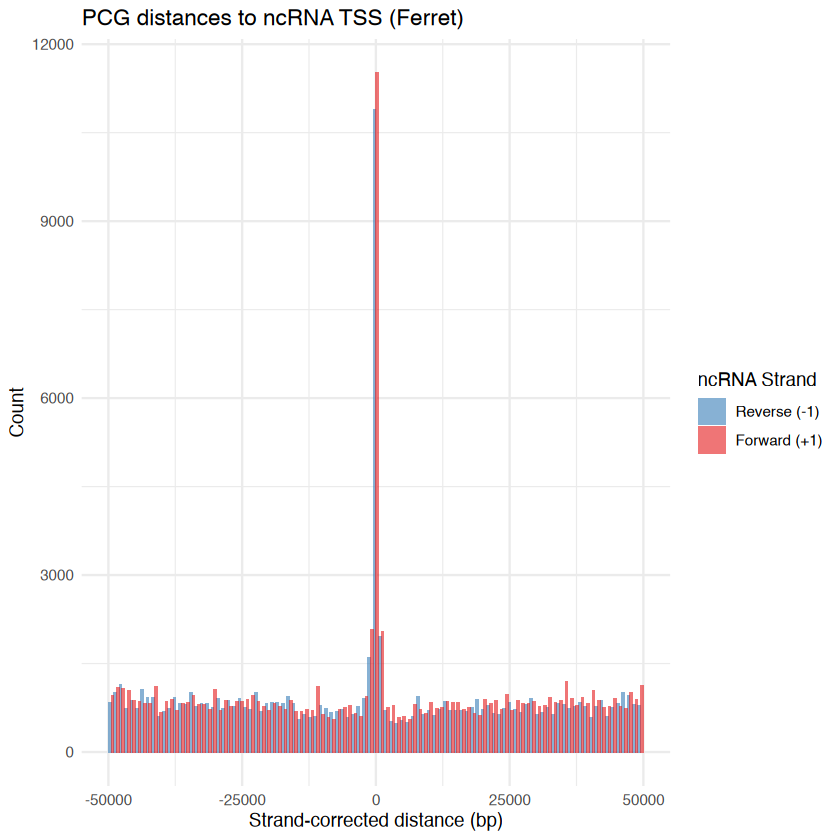

In [58]:
# plot the distances
distances_list_filtered[["mouse"]] %>% filter(dna_distance >= -50000 & dna_distance <= 50000) %>%
     filter(gene_biotype == "lncRNA") %>%
    mutate(ncrna_strand = as.character(ncrna_strand)) %>%
    ggplot(aes(x = strand_distance, fill = ncrna_strand)) +
    geom_histogram(position = "dodge", alpha = 0.6, bins = 100) +
    scale_fill_manual(values = c("1" = "#E41A1C", 
                                 "-1" = "#377EB8"),
                      labels = c("1" = "Forward (+1)", "-1" = "Reverse (-1)")) +
    labs(title = "PCG distances to ncRNA TSS (Ferret)",
         x = "Strand-corrected distance (bp)",
         y = "Count",
         fill = "ncRNA Strand") +
    theme_minimal()